In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [12]:
df = pd.read_csv("../dataset/other_assets/infs/eth-usd-inf.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)


In [13]:
data = df.copy()

In [ ]:
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

In [18]:
import json
def get_mse_vals(inf_path, pred_len, target = 'close'):
    """
    Get the MSE values for the inference data.

    args:
        inf_path: path to the inference data
        pred_len: number of predictions to get MSE values for
        target: target column
    """
    data = pd.read_csv(inf_path)
    pred_len = data.columns.str.contains('predicted').sum()
    mse_vals = {}
    print(data.columns)
    try:
        errors = {f'pred_{pred}': [] for pred in range(1, pred_len+1)}
        for i in range(len(data) - pred_len):
            row = data.iloc[i]
            if pd.isna(row[f'{target}_predicted_1']):
                continue
            for pred in range(1, pred_len+1):
                next_row = data.iloc[i+pred]
                if pd.notna(row[f'{target}_predicted_{pred}']):
                    error = row[f'{target}_predicted_{pred}'] - next_row[target]
                    sq_error = error ** 2
                    errors[f'pred_{pred}'].append(sq_error)

        for pred in range(1, pred_len+1):
            mse_vals[f'inf_pred_{pred}_mse'] = np.mean(errors[f'pred_{pred}'])
    except Exception as e:
        print(f"Error getting MSE values: {e}")
        raise ValueError(f"Error getting MSE values: {e}")

    return mse_vals

def create_metrics_json(mlflow_run_id, llm_model, experiment_name, summary_table, mda_vals, trial_dict):
    """
    Create the metrics dataframe.

    args:
        summary_table: summary table
        mda_vals: mda values
    """
    metrics_dict = {}

    # Creates two metrics. The next candle prediction and the last candle prediction.

    metrics_dict["mlflow_run_id"] = mlflow_run_id
    metrics_dict["llm_model"] = llm_model
    metrics_dict["experiment_name"] = experiment_name
    metrics_dict["summary_table"] = summary_table.to_dict()
    metrics_dict["trial_parameters"] = trial_dict
    metrics_dict["inf_analysis"] = mda_vals

    metrics_json = json.dumps(metrics_dict)

    return metrics_json



In [ ]:
def get_mda_vals(inf_path, target = 'close'):
    """
    Perform analysis on the inference data.

    args:
        client: mlflow client
        new_data_path: path to the new data
    """

    data = pd.read_csv(inf_path)
    pred_len = data.columns.str.contains('predicted').sum()

    mda_vals = {}

    
    for pred in range(1, pred_len+1):
        pred_col = f'{target}_predicted_{pred}'
        
        if pred_col not in data.columns:
            print(f"Column {pred_col} not found in data.")
            continue
        
        # Find rows where this prediction column has values (not NaN)
        valid_pred_mask = data[pred_col].notna()
        valid_pred_indices = data.index[valid_pred_mask].values
        
        if len(valid_pred_indices) == 0:
            print(f"No valid predictions found in {pred_col}")
            continue
        
        # For each valid prediction, we need to check if we have the future actual value
        # The prediction at index i predicts the value at index i+pred
        valid_comparisons = []
        
        for idx in valid_pred_indices:
            future_idx = idx + pred
            
            # Check if future actual value exists in the dataframe
            if future_idx < len(data) and pd.notna(data[target].iloc[future_idx]):
                current_actual = data[target].iloc[idx]
                predicted_value = data[pred_col].iloc[idx]
                future_actual = data[target].iloc[future_idx]
                
                # Calculate directions
                predicted_direction = predicted_value - current_actual
                actual_direction = future_actual - current_actual
                
                # Check if signs match
                correct = (predicted_direction * actual_direction) > 0
                valid_comparisons.append(correct)
        
        if len(valid_comparisons) == 0:
            print(f"No valid comparisons for prediction horizon {pred}")
            continue
        
        # Calculate directional accuracy
        mda = np.mean(valid_comparisons)
        mda_vals[f'inf_pred_{pred}_mda'] = mda

    return mda_vals


In [ ]:
def all_mape_vals(data, pred_len, target='close'):
    mape_vals = pd.DataFrame()

    for index, row in data.iterrows():
        if row[f'{target}_predicted_1'] is None:
            continue
        if index >= len(data) - pred_len:
            break

        for pred in range(1, pred_len + 1):
            actual = data.loc[index + pred, target]
            predicted = row[f'{target}_predicted_{pred}']

            if actual == 0 or pd.isna(actual):
                mape_vals.loc[index, f'inf_pred_{pred}_mape'] = None
            else:
                mape_vals.loc[index, f'inf_pred_{pred}_mape'] = abs((predicted - actual) / actual)

    return mape_vals



In [93]:
def calc_volatility(prices, window=20, annualize=False, periods_per_year=252):
    """
    Calculate rolling volatility using log returns.
    
    prices: pd.Series of prices
    window: rolling window size
    annualize: whether to annualize volatility
    """
    returns = prices.pct_change()
    vol = returns.rolling(window).std()

    if annualize:
        vol = vol * np.sqrt(periods_per_year)

    return vol

def calc_overall_volatility(prices, annualize=False, periods_per_year=252):
    """
    Calculate overall volatility using percentage returns.
    
    prices: pd.Series of prices
    annualize: whether to annualize volatility
    """
    returns = prices.pct_change().dropna()
    vol = returns.std()

    if annualize:
        vol = vol * np.sqrt(periods_per_year)

    return vol




In [99]:
assets = [
    "AAPL",
    "ADA-USD",
    "BCH-USD",
    "BTC-USD",
    "ETH-USD",
    "EURUSD-X",
    "JPY-X",
    "NVDA",
    "SOL-USD",
    "TSLA",
    "XRP-USD"
]
all_mapes = {}

window = 30

for asset in assets:
    df = pd.read_csv(f"../dataset/other_assets/infs/{asset}-inf.csv")
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    df.reset_index(drop=True, inplace=True)

    periods = 252 if asset in ["AAPL", "NVDA", "TSLA"] else 365

    mapes = all_mape_vals(df, 24).copy()

    all_mapes[asset] = mapes



In [101]:
normal_mapes = {}
for asset in assets:
    df = pd.read_csv(f"../dataset/other_assets/infs/{asset}-inf.csv")
    periods = 252 if asset in ["AAPL", "NVDA", "TSLA"] else 365
    vol = calc_overall_volatility(df["close"], annualize=True, periods_per_year=periods)
    normal_mapes[asset] = all_mapes[asset]/vol

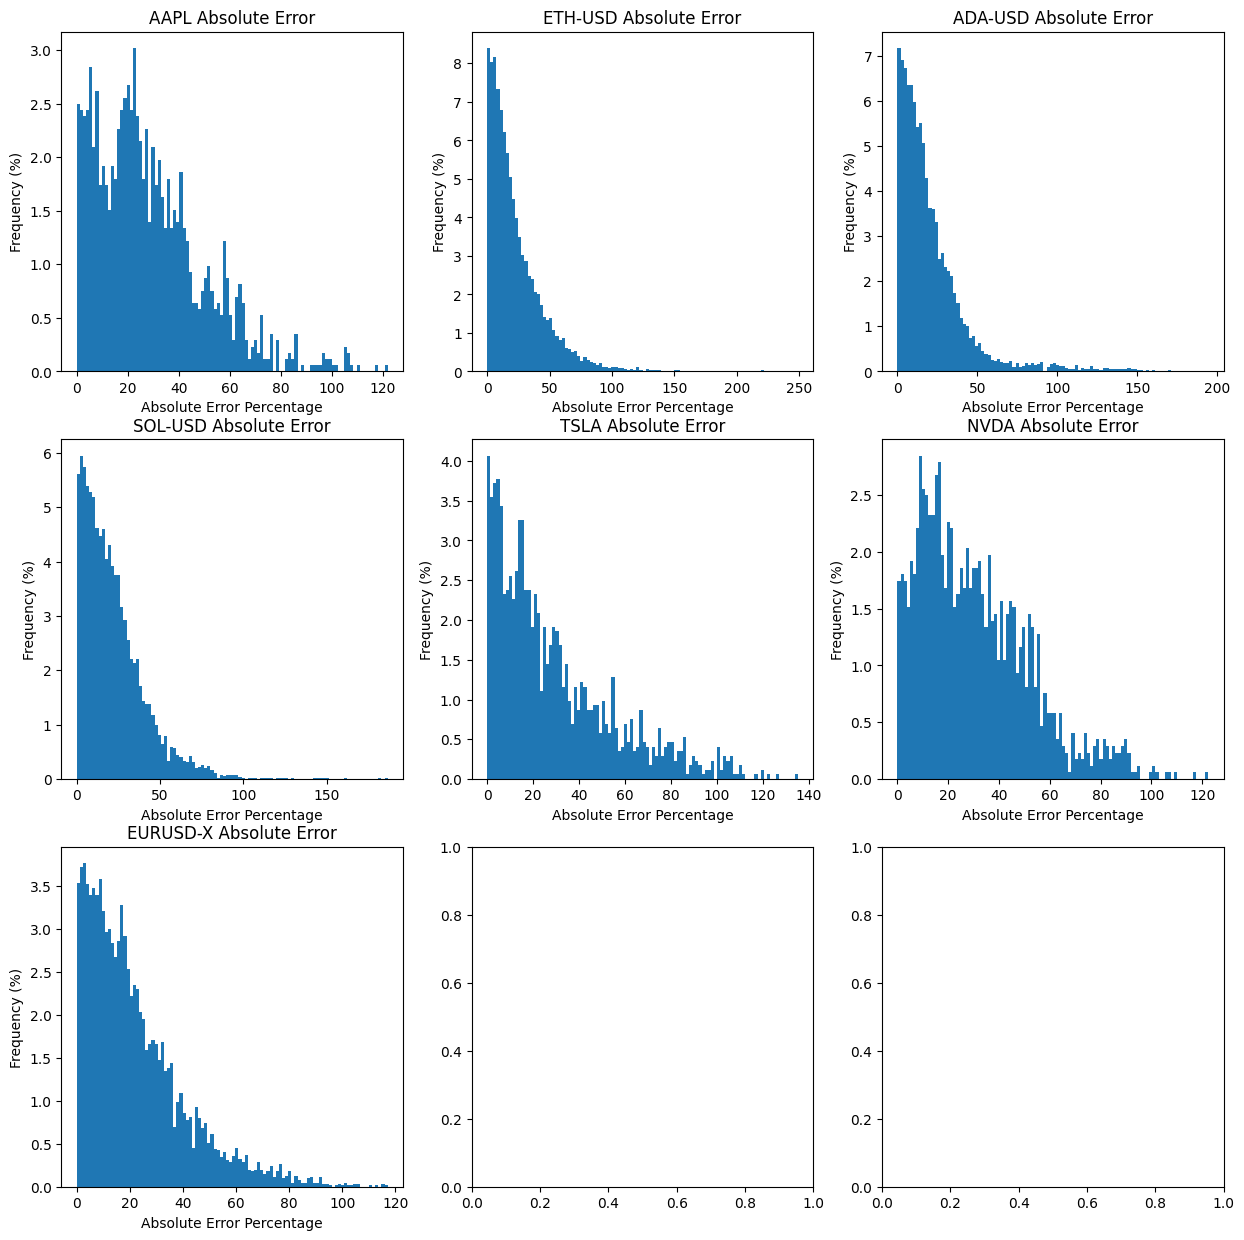

In [ ]:
assets = ["AAPL", "ETH-USD","ADA-USD","SOL-USD","TSLA","NVDA","EURUSD-X"]
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i in range(len(assets)):
    pred = 24
    asset = assets[i]
    mapes = normal_mapes[asset]
    j = i % 3

    axs[i//3,j].hist(mapes[f"inf_pred_{pred}_mape"].values * 100, bins = 100, weights=np.ones(len(mapes)) / len(mapes) * 100)
    axs[i//3,j].set_xlabel("Absolute Error Percentage")
    axs[i//3,j].set_ylabel("Frequency (%)")
    axs[i//3,j].set_title(f"{asset} Absolute Error")

plt.show()

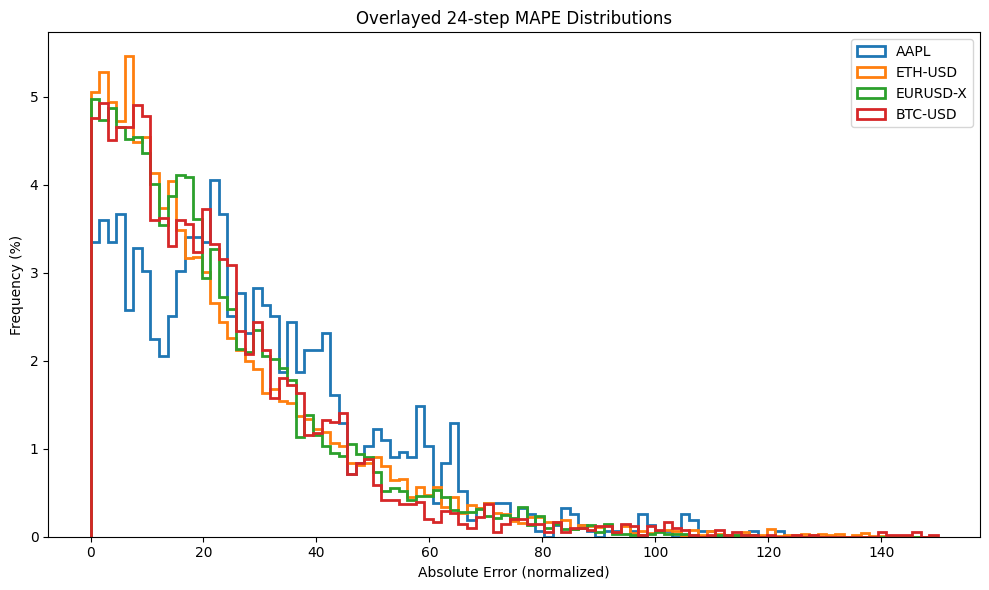

In [150]:
bins = np.linspace(0, 150, 100)  # choose once, reuse everywhere
stocks = [
    "AAPL",
    "NVDA",
    "TSLA"
]

cryptos = [
    "ADA-USD",
    "BCH-USD",
    "BTC-USD",
    "ETH-USD",
    "SOL-USD",
    "XRP-USD"
]

fx = [
    "EURUSD-X",
    "JPY-X"
]

three = [
    "AAPL",
    "ETH-USD",
    "EURUSD-X",
    "BTC-USD",
]

plt.figure(figsize=(10, 6))

for asset in three:
    df = pd.read_csv(f"../dataset/other_assets/infs/{asset}-inf.csv")
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

    mapes = normal_mapes[asset]

    vals = mapes[f"inf_pred_{pred}_mape"].dropna().values * 100

    plt.hist(
        vals,
        bins=bins,
        weights=np.ones(len(vals)) / len(vals) * 100,
        histtype="step",
        linewidth=2,
        label=asset
    )


plt.xlabel("Absolute Error (normalized)")
plt.ylabel("Frequency (%)")
plt.title(f"Overlayed {pred}-step MAPE Distributions")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
mape_vals = {}
mda_vals = {}
for asset in assets:
    df = pd.read_csv(f"../dataset/other_assets/infs/{asset}-inf.csv")
    mape_vals[asset] = np.mean(all_mapes[asset][f"inf_pred_24_mape"].dropna().values)
    
    mapes = normal_mapes[asset]


In [148]:
mape_vals = {}
mda_vals = {}
for asset in assets:
    asset_path = f"../dataset/other_assets/infs/{asset}-inf.csv"
    df = pd.read_csv(asset_path)
    mape_vals[asset] = np.mean(all_mapes[asset][f"inf_pred_1_mape"].dropna().values)
    mda_vals[asset] = np.mean(get_mda_vals(asset_path)[f"inf_pred_1_mda"])



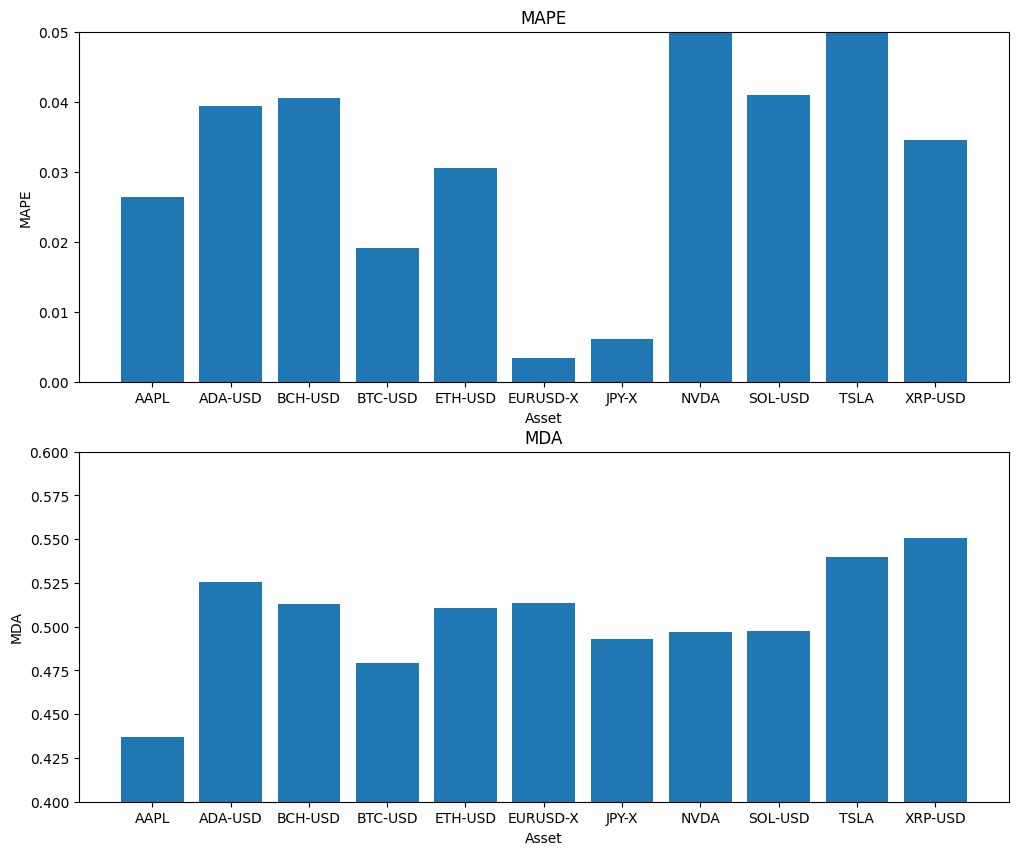

In [138]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))
axs[0].bar(mape_vals.keys(), mape_vals.values())
axs[1].bar(mda_vals.keys(), mda_vals.values())
axs[0].set_ylabel("MAPE")
axs[0].set_xlabel("Asset")
axs[1].set_ylabel("MDA")
axs[1].set_xlabel("Asset")
axs[0].set_title("MAPE")
axs[1].set_title("MDA")
axs[0].set_ylim(0, .05)
axs[1].set_ylim(.4, .6)
plt.show()

In [149]:
import pandas as pd
vols = {}

# Create a DataFrame from the mape_vals and mda_vals dictionaries
for asset in assets:
    vol = calc_overall_volatility(df["close"], annualize=True, periods_per_year=periods)
    vols[asset] = vol

table_df = pd.DataFrame({
    "Asset": list(mape_vals.keys()),
    "MAPE": [mape_vals[a] for a in mape_vals.keys()],
    "MDA": [mda_vals[a] for a in mda_vals.keys()],
})


# Reorder columns for clarity
table_df = table_df[["Asset", "MDA", "MAPE"]]

# Display the table
display(table_df)


,Asset,MDA,MAPE
0,AAPL,0.507614,0.017972
1,ADA-USD,0.506227,0.026667
2,BCH-USD,0.515307,0.026670
3,BTC-USD,0.512393,0.012329
4,ETH-USD,0.520894,0.020099
5,EURUSD-X,0.464226,0.002244
6,JPY-X,0.496320,0.004005
7,NVDA,0.500635,0.040882
8,SOL-USD,0.509952,0.027260
9,TSLA,0.487944,0.047460
